In [1]:
# Utils
# ==============================================================================
import warnings

# Plot
# ==============================================================================
import pandas as pd
import numpy as np

# Data Preprocessing
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
# ==============================================================================
from scipy.stats import ttest_ind, ttest_1samp, f_oneway


# **Info**
---
**@By**: Steven Bernal

**@Nickname**: Kaiziferr

**@Git**: https://github.com/Kaiziferr

# **Data dictionary**
---

* `age`: age of primary beneficiary
* `sex`: insurance contractor gender, female, male
* `bmi`: body mass index, providing an understanding of body, weights that are relatively high or low relative to height,
objective index of body weight (kg / m ^ 2) using the ratio of height to weight, ideally 18.5 to 24.9
* `children`: number of children covered by health insurance / Number of dependents
* `smoker`: smoking
* `region`: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.
* `charges`: individual medical costs billed by health insurance

# **Utils**
---

In [2]:
def null_percentage_per_feature(data: pd.DataFrame, **kwargs) -> None:
    """
    Generate a horizontal distribution plot showing the percentage of null
    values per feature in a DataFrame.

    Parameters
    ----------
    data : pandas.DataFrame
        Input DataFrame used to compute null value percentages.

    **kwargs :
        Additional keyword arguments passed to seaborn.displot().set()
        for plot customization (e.g., title, labels).

    Returns
    -------
    None
        Does not return a value. Displays the null percentage distribution plot.
    """
    try:
        ticklabels = (
            data.isnull()
            .melt()
            .pipe(
                lambda df: sns.displot(
                    data=df,
                    y='variable',
                    hue='value',
                    multiple='fill',
                    aspect=5
                ).set(**kwargs)
            )
        )

        p = data.isnull().sum() / data.shape[0]

        for i, (feature, value) in enumerate(p.items()):
            if value > 0:
                ticklabels.ax.text(
                    value + 0.015,
                    i + 0.2,
                    f'{round(value * 100, 2)}%',
                    ha="center",
                    color='w',
                    fontweight='bold'
                )
    except Exception as e:
        print(e)


def plot_numeric_distributions(data: pd.DataFrame,
                               nrows: int = 3,
                               ncols: int = 3,
                               figsize: tuple = (9, 6),
                               fontsize_title: int = 12,
                               palette=None,
                               show_stats=None) -> None:

    """
    Plot histograms with KDE for all numeric features in a DataFrame.

    Parameters
    ----------
    data : pandas.DataFrame
        Input DataFrame containing numeric features to visualize.

    nrows : int, default=3
        Number of subplot rows.

    ncols : int, default=3
        Number of subplot columns.

    figsize : tuple, default=(9, 6)
        Figure size as (width, height).

    fontsize_title : int, default=12
        Font size for the main figure title.

    palette : None, str, list or dict
        - None → usa colores por defecto
        - str → nombre de paleta seaborn
        - list → lista de colores
        - dict → {"columna": "color"}

    show_stats : None, str or list, default=None
        - None → no muestra estadísticas
        - "all" → muestra mean, median y mode
        - list → ["mean", "median", "mode"]

    Returns
    -------
    None
        Does not return a value. Displays the distribution plots.
    """

    try:
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
        axes = axes.flat

        numeric_columns = data.select_dtypes(include=np.number).columns

        if show_stats == "all":
            show_stats = ["mean", "median", "mode"]

        if palette is None:
            colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
        elif isinstance(palette, str):
            colors = sns.color_palette(palette, len(numeric_columns))
        elif isinstance(palette, list):
            colors = palette
        elif isinstance(palette, dict):
            colors = None
        else:
            raise ValueError("palette must be None, str, list or dict")

        for i, column in enumerate(numeric_columns):

            # Selección de color
            if isinstance(palette, dict):
                color = palette.get(
                    column,
                    plt.rcParams['axes.prop_cycle'].by_key()['color'][i % 10]
                )
            else:
                color = colors[i % len(colors)]

            ax = axes[i]

            sns.histplot(
                data=data,
                x=column,
                stat="count",
                kde=True,
                color=color,
                ax=ax
            )

            if show_stats:
                series = data[column].dropna()

                if "mean" in show_stats:
                    ax.axvline(series.mean(), color="black", linestyle="--", label="Mean")

                if "median" in show_stats:
                    ax.axvline(series.median(), color="blue", linestyle=":", label="Median")

                if "mode" in show_stats and not series.mode().empty:
                    ax.axvline(series.mode().iloc[0], color="red", linestyle="-.", label="Mode")

                ax.legend(fontsize=7)

            ax.set_title(column, fontsize=10)
            ax.tick_params(labelsize=8)
            ax.set_xlabel("")

        fig.tight_layout()
        plt.subplots_adjust(top=0.9)
        fig.suptitle('Numeric Feature Distributions', fontsize=fontsize_title)

    except Exception as e:
        print(e)


def plot_numeric_boxplots(data: pd.DataFrame,
                          nrows: int = 3,
                          ncols: int = 3,
                          figsize: tuple = (9, 6),
                          fontsize_title: int = 12,
                          width: float = 0.4) -> None:
  """
  Plot outlined (no fill) boxplots for all numeric features in a DataFrame.

  Parameters
  ----------
  data : pandas.DataFrame
      Input DataFrame containing numeric features.

  nrows : int, default=3
      Number of subplot rows.

  ncols : int, default=3
      Number of subplot columns.

  figsize : tuple, default=(9, 6)
      Figure size as (width, height).

  fontsize_title : int, default=12
      Font size for the main figure title.

  width : float, default=0.4
      Width of each boxplot.

  Returns
  -------
  None
      Displays the boxplots.
  """

  try:
      fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
      ax = ax.flat

      numeric_columns = data.select_dtypes(include=np.number).columns

      for i, column in enumerate(numeric_columns):
          color = (list(plt.rcParams['axes.prop_cycle']) * 2)[i]["color"]

          sns.boxplot(
              data=data,
              x=column,
              ax=ax[i],
              width=width,
              boxprops=dict(facecolor='none', edgecolor=color),
              whiskerprops=dict(color=color),
              capprops=dict(color=color),
              medianprops=dict(color=color),
              flierprops=dict(markeredgecolor=color)
          )

          ax[i].set_title(column, fontsize=10)
          ax[i].tick_params(labelsize=8)
          ax[i].grid(False)
          ax[i].set_xlabel("")

      fig.tight_layout()
      plt.subplots_adjust(top=0.9)
      fig.suptitle('Numeric Feature Boxplots', fontsize=fontsize_title)

  except Exception as e:
      print(e)



def plot_categorical_donut_charts(data: pd.DataFrame,
                                   nrows: int = 1,
                                   ncols: int = 3,
                                   figsize: tuple = (9, 6),
                                   fontsize_title: int = 12,
                                   donut_width: float = 0.7,
                                   autopct_format: str = '%1.1f%%',
                                   c: dict=None) -> None:
  """
  Plot donut charts for all categorical (object) features in a DataFrame.

  Parameters
  ----------
  data : pandas.DataFrame
      Input DataFrame containing categorical features.

  nrows : int, default=1
      Number of subplot rows.

  ncols : int, default=3
      Number of subplot columns.

  figsize : tuple, default=(9, 6)
      Figure size as (width, height).

  fontsize_title : int, default=12
      Font size for the main figure title.

  donut_width : float, default=0.7
      Radius of the white circle to create donut effect.

  autopct_format : str, default='%1.1f%%'
      Format string for percentage labels.

  color_dict : dict, default=None
        Dictionary of colors per column

  Returns
  -------
  None
      Displays the donut charts.
  """

  fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
  ax = ax.flat

  category_columns = data.select_dtypes(include='object').columns

  for i, column in enumerate(category_columns):

      if i >= len(ax):
          break

      value_counts = data[column].value_counts()
      color_cycle = list(plt.rcParams['axes.prop_cycle'])
      if c and column in c:
        colors = [
            c[column].get(cat, 'gray')
            for cat in value_counts.index
            ]
      else:
        colors = [color_cycle[j % len(color_cycle)]["color"]
                  for j in range(len(data[column].value_counts()))]


      ax[i].pie(
          value_counts,
          labels=value_counts.index,
          autopct=lambda pct: f"{int(round(pct * sum(value_counts) / 100.0))} ({pct:1.1f}%)",
          colors=colors,
          textprops={'fontsize': 8}
      )

      # Donut effect
      centre_circle = plt.Circle((0, 0), donut_width, color='white')
      ax[i].add_artist(centre_circle)

      ax[i].set_title(column, fontsize=10)

  fig.tight_layout()
  plt.subplots_adjust(top=0.8)
  fig.suptitle('Categorical Feature Distribution', fontsize=fontsize_title)

# **Config**
---

In [3]:
random_seed = 12345
warnings.filterwarnings('ignore')
sns.set_style('darkgrid')
title_data = 'Medical Cost Personal Datasets'
paleta = {
    'sex': {
        'female': '#FF6B6B',
        'male': '#4ECDC4'
    },
    'smoker': {
        'no': '#2ECC71',
        'yes': '#E74C3C'
    },
    'region': {
        'northeast': '#1A535C',
        'northwest': '#6A4C93',
        'southeast': '#FFA500',
        'southwest': '#00BFFF'
    },
}
p={
    "age": "#FFB347",
    "charges": "#8E44AD",
    "children": "#FF6F91",
    "bmi": "#FFD93D"
}

# **Data**
---

In [4]:
url = 'https://drive.google.com/file/d/1h8Nm4j55FCp00auZYLvidR_QUHB6HZwx/view?usp=sharing'
url = 'https://drive.google.com/uc?id=' + url.split('/')[-2]
data = pd.read_csv(url)

# **Exploratory Data Analysis (EDA)**
---

**Variable types**
---


In [5]:
data.shape

(1338, 7)

There are 1,338 rows and 7 columns.

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


The dataset contains 3 object-type features, 2 integer features, and 2 float features.

**Missing data**
---

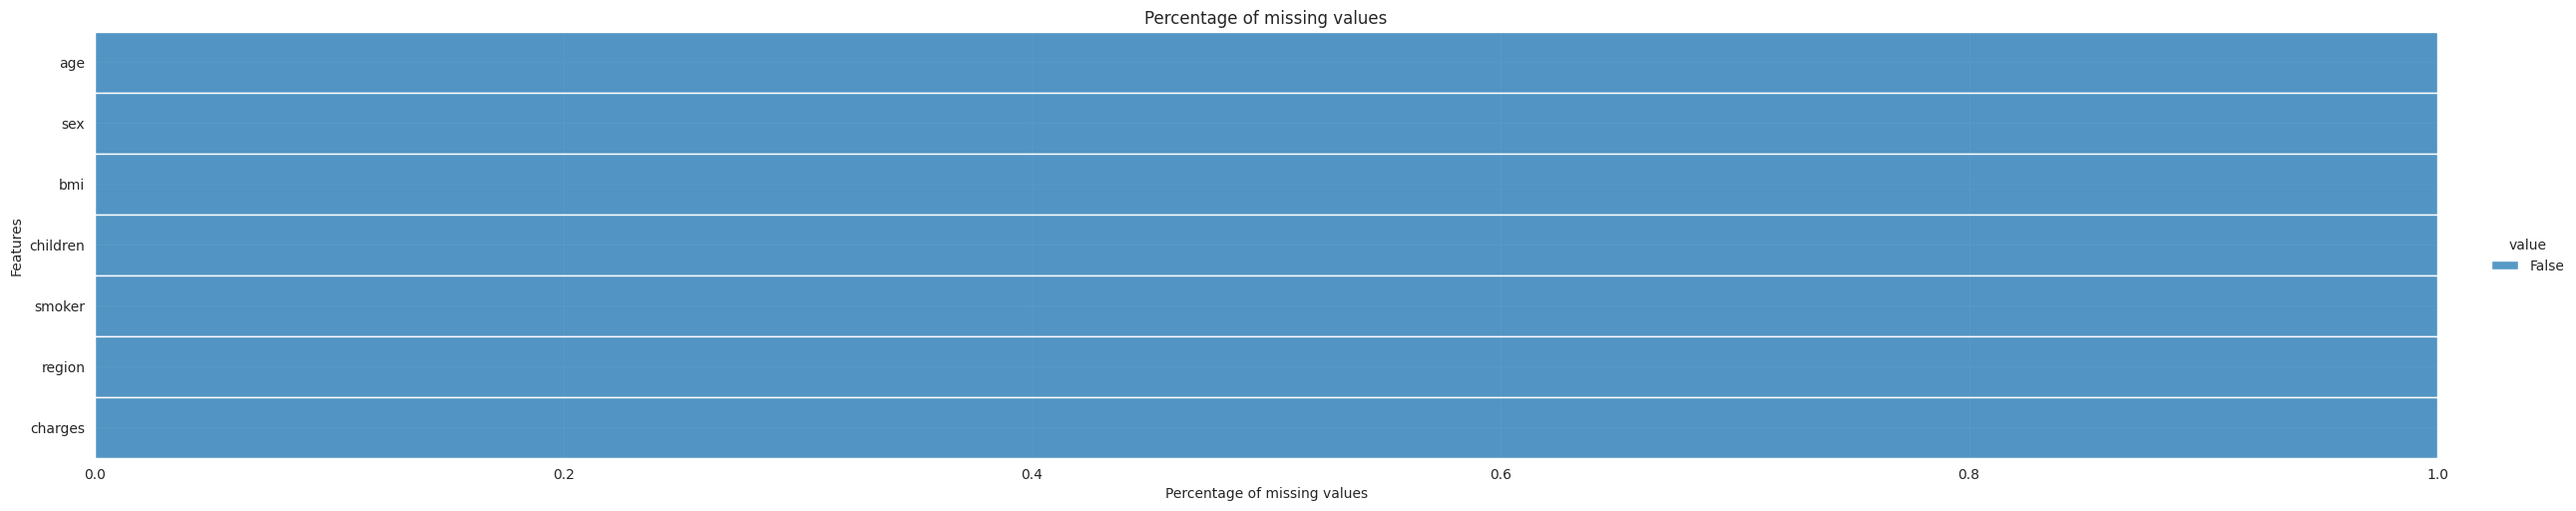

In [7]:
null_percentage_per_feature(data, title="Percentage of missing values", xlabel='Percentage of missing values', ylabel='Features')

There are no missing values.

**Constants**
---

In [8]:
isConstan_object = data.describe(include='object').loc['unique']
isConstan_object = isConstan_object[isConstan_object == 1]
isConstan_object

,unique


In [9]:
isConstan_numeric = data.describe().loc['std']
isConstan_numeric[isConstan_numeric<=0]

,std


The dataset does not contain any constant features.

**Univariate EDA**
---

In [10]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
data.describe(include='object')

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


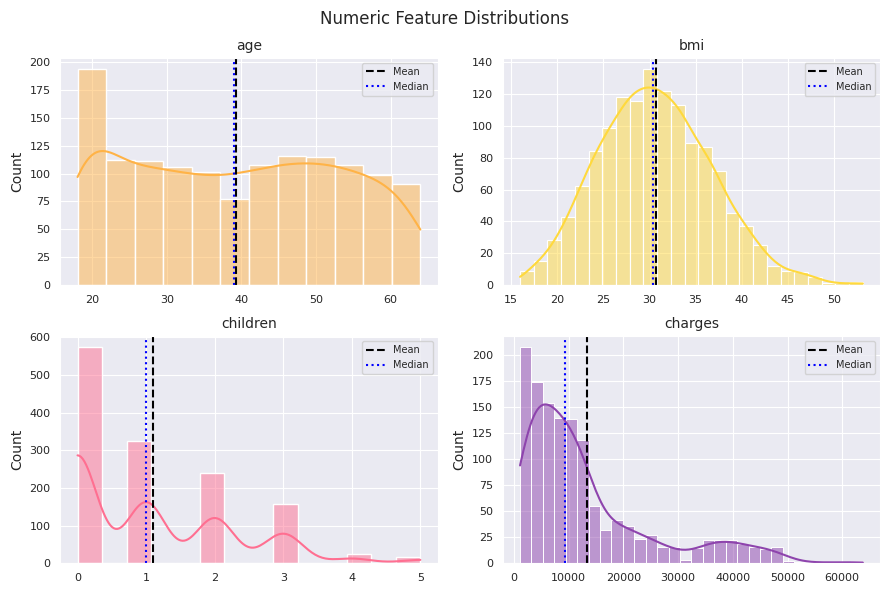

In [12]:
plot_numeric_distributions(data, 2, 2, palette=p, show_stats=['mean', 'median'])

- The dataset has a sample size of 1,338 observations.


**age**
- The age distribution is relatively uniform, although there is a higher concentration in younger ages (around 18–25 years).
- The mean (39) and the median (38) are very similar, which indicates that there is no strong skewness in the distribution.
- The approximate age range goes from 18 to 64 years.
- The sample contains individuals from a wide age range and is relatively balanced.

**bmi**
- The distribution is approximately normal (bell-shaped).
- Most values are concentrated between 25 and 35.
- A large portion of the population is overweight or close to obesity levels.

**children**

- The distribution is discrete and right-skewed.
- Most individuals have 0 or 1 child.
- Very few individuals have 4 or 5 children.
- The mean (1.1) is slightly higher than the median (1).
- The dataset population is mainly composed of individuals with few or no children.


**charges**
- The distribution is strongly right-skewed.
- The mean (13,000) is higher than the median (9,000), indicating that some very high values increase the average.
- Most medical expenses are below 15,000, but there are outliers exceeding 40,000–60,000.
- Most people have moderate medical expenses, but a small group shows extremely high costs

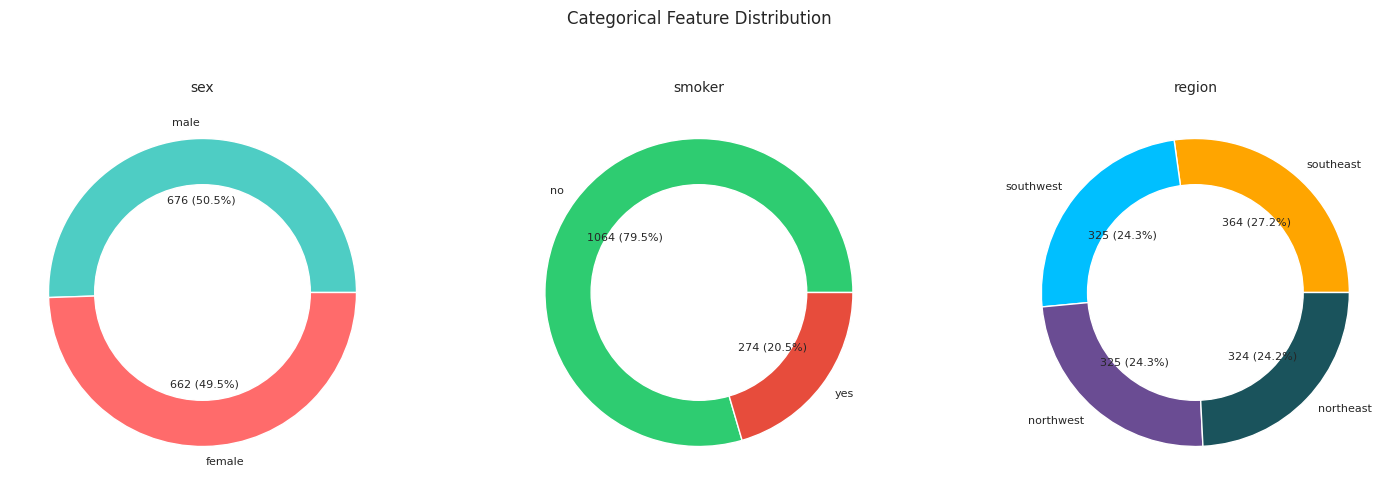

In [13]:
plot_categorical_donut_charts(data, 1, 3, figsize=(15, 5), c=paleta)

- There are two genders, and their proportions are nearly balanced: 50.5% male and 49.5% female.

- There is a relative imbalance of approximately 74%, representing a moderate imbalance. For every 3.8 smokers, there is 1 non-smoker.

- The regions show a similar proportion in the dataset.

**Bivariate EDA**
---

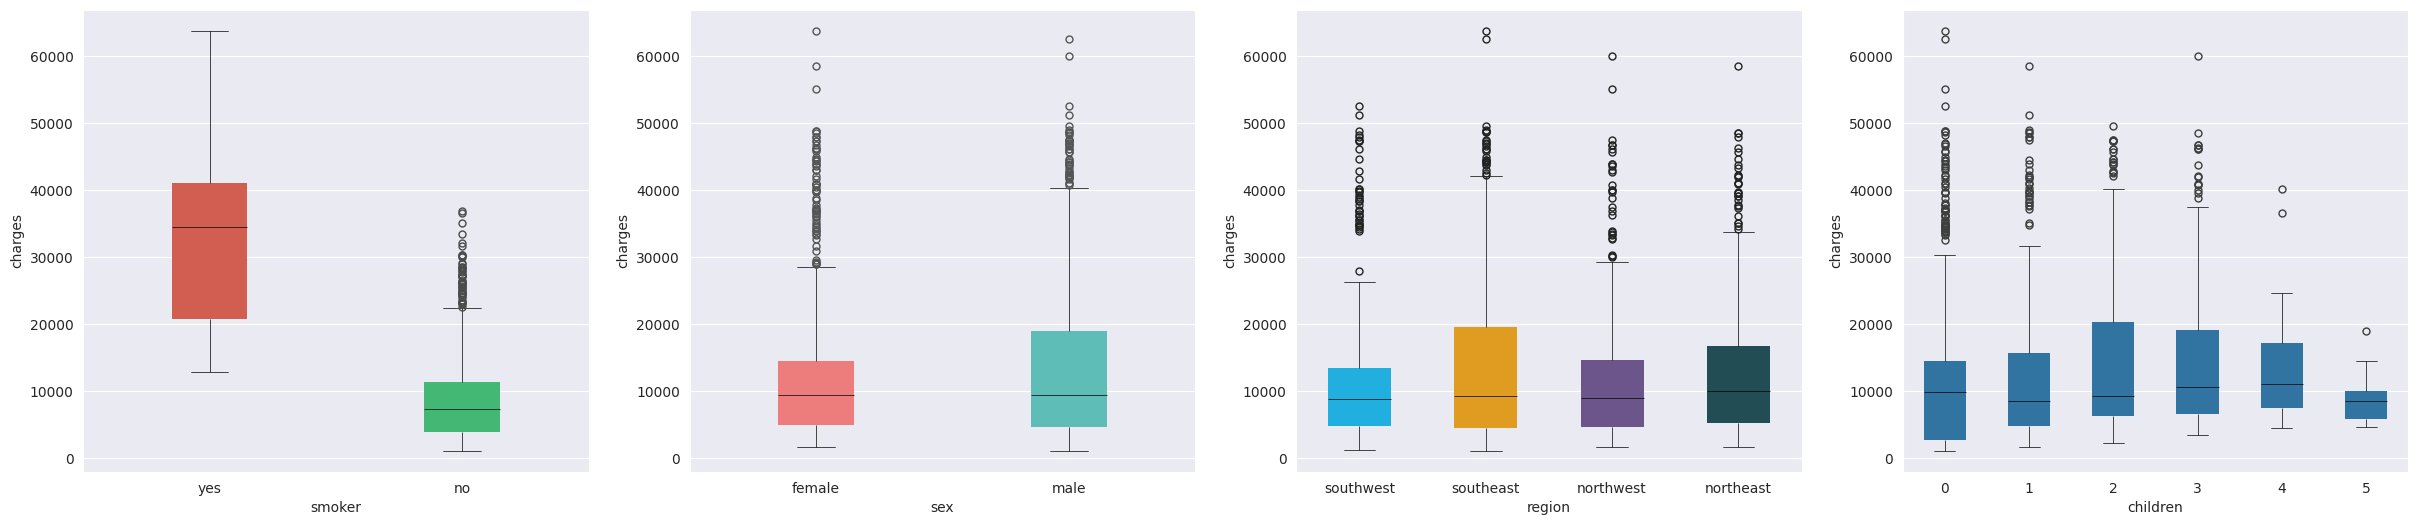

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(30, 6))

sns.boxplot(
    x=data["smoker"],
    y=data["charges"],
    palette=paleta['smoker'],
    boxprops=dict(linewidth=0),
    whiskerprops=dict(color='black', linewidth=0.5),
    capprops=dict(color='black',linewidth=0.5),
    medianprops=dict(color='black',linewidth=0.5),
    width=0.3,
    flierprops = dict(
        marker='o',
        markersize=5,
        linestyle='none'
    ),
    ax=ax[0])

sns.boxplot(
    x=data["sex"],
    y=data["charges"],
    palette=paleta['sex'],
    boxprops=dict(linewidth=0),
    whiskerprops=dict(color='black', linewidth=0.5),
    capprops=dict(color='black',linewidth=0.5),
    medianprops=dict(color='black',linewidth=0.5),
    width=0.3,
    flierprops = dict(
        marker='o',
        markersize=5,
        linestyle='none'
    ),
    ax=ax[1])

sns.boxplot(
    x=data["region"],
    y=data["charges"],
    palette=paleta['region'],
    boxprops=dict(linewidth=0),
    whiskerprops=dict(color='black', linewidth=0.5),
    capprops=dict(color='black',linewidth=0.5),
    medianprops=dict(color='black',linewidth=0.5),
    width=0.5,
    flierprops = dict(
        marker='o',
        markersize=5,
        linestyle='none'
    ),
    ax=ax[2])


sns.boxplot(
    x=data["children"].astype('object'),
    y=data["charges"],
    #palette=paleta['region'],
    #hue_order=data["children"].unique().astype("str"),
    boxprops=dict(linewidth=0),
    whiskerprops=dict(color='black', linewidth=0.5),
    capprops=dict(color='black',linewidth=0.5),
    medianprops=dict(color='black',linewidth=0.5),
    width=0.5,
    flierprops = dict(
        marker='o',
        markersize=5,
        linestyle='none'
    ),
    ax=ax[3])

plt.show()

**Charges by Smoker**

- Smokers ("yes") have significantly higher medical charges, with a median of around 34,000, compared to non-smokers, whose median is much lower (around 8,000).

- The dispersion (interquartile range) and maximum charges are also higher for smokers, indicating a clear impact of smoking on charges, but without extreme outliers.

**Charges by sex**

- Males tend to have slightly higher median charges (9,000) than females (8,000).

- The range of charges is wider for males, with some extreme high charges (outliers) observ

**Charges by Region:**

- The median charges vary somewhat by region: the Southeast shows the highest median charges, followed by Northeast, Northwest, and Southwest.

- All regions have outliers with very high charges, but Southeast stands out with more extreme values.

**Charges by Number of Children**

- Median charges generally increase with the number of children up to 3, then decrease for 4 and 5 children.

- Those with 0 children have the lowest median charges.

- Outliers exist across all groups, indicating individuals with very high charges regardless of number of children.

**Multivariate EDA**
---

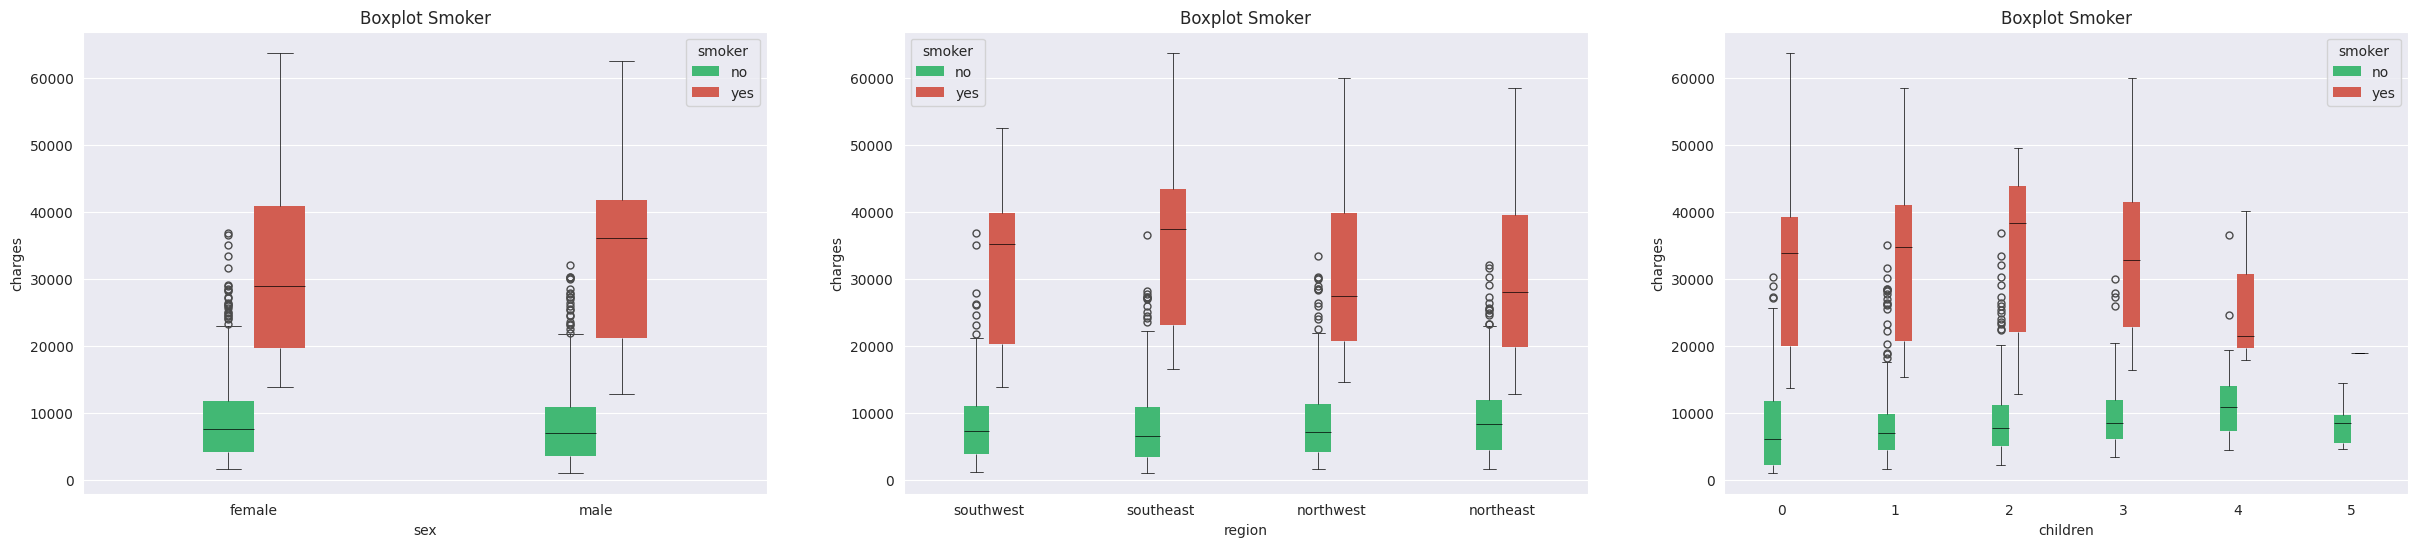

In [15]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 6))

sns.boxplot(
    x=data["sex"],
    y=data["charges"],
    palette=paleta['smoker'],
    hue=data["smoker"],
    hue_order=['no', 'yes'],
    boxprops=dict(linewidth=0),
    whiskerprops=dict(color='black', linewidth=0.5),
    capprops=dict(color='black',linewidth=0.5),
    medianprops=dict(color='black',linewidth=0.5),
    width=0.3,
    flierprops = dict(
        marker='o',
        markersize=5,
        linestyle='none'
    ),
    ax=ax[0])
ax[0].set_title('Boxplot Smoker')


sns.boxplot(
    x=data["region"],
    y=data["charges"],
    palette=paleta['smoker'],
    hue=data["smoker"],
    hue_order=['no', 'yes'],
    boxprops=dict(linewidth=0),
    whiskerprops=dict(color='black', linewidth=0.5),
    capprops=dict(color='black',linewidth=0.5),
    medianprops=dict(color='black',linewidth=0.5),
    width=0.3,
    flierprops = dict(
        marker='o',
        markersize=5,
        linestyle='none'
    ),
    ax=ax[1])
ax[1].set_title('Boxplot Smoker')


sns.boxplot(
    y=data["charges"],
    x=data["children"].astype('object'),
    palette=paleta['smoker'],
    hue=data["smoker"],
    hue_order=['no', 'yes'],
    boxprops=dict(linewidth=0),
    whiskerprops=dict(color='black', linewidth=0.5),
    capprops=dict(color='black',linewidth=0.5),
    medianprops=dict(color='black',linewidth=0.5),
    width=0.3,
    flierprops = dict(
        marker='o',
        markersize=5,
        linestyle='none'
    ),
    ax=ax[2])
ax[2].set_title('Boxplot Smoker')

plt.show()

**charges by sex and smoker**

**Observations**

- Smokers ("yes") have much higher costs than non-smokers.
- This pattern holds for both men and women.

**Dispersion**

- Smokers show greater variability (larger boxes).
- They also exhibit high extreme values.

**Comparison by Sex**

- No strong difference is observed between male and female smokers.
- The distributions are very similar.

**Statistical Interpretation**

- Smoking has a strong effect on medical costs.
- Sex does not appear to significantly modify this effect.

**charges by sex and smoker**

**Observations**
- Across all regions, smokers exhibit significantly higher medical costs than non-smokers.

**Dispersion**
- The dispersion of medical costs is much greater among smokers, with wider interquartile ranges and numerous outliers.

- The Southeast region appears to show slightly higher dispersion, suggesting greater variability in medical costs in that area.

**Comparison by regions**
- The distributions for smokers are relatively similar across regions.
- Non-smokers maintain consistently low and stable values.

**Statistical Interpretation**
- The observations suggest that the effect of smoking dominates over regional variability


**charges by sex and children**

**Observations**
- It is observed that smokers have considerably higher medical costs than non-smokers, regardless of the number of children.

**Dispersion**

- Smokers show greater dispersion in medical costs, with several high outliers.

- Non-smokers exhibit less dispersion, with values concentrated in relatively low ranges.


**Comparison by children**

- No clear pattern of increasing costs is observed as the number of children increases.

- The distributions remain relatively stable.

- This suggests that the number of children does not appear to be a determining factor in medical costs.

**Statistical Interpretation**

- The observations indicate that the number of children may have limited influence on medical costs, especially compared to the effect of smoking habits.



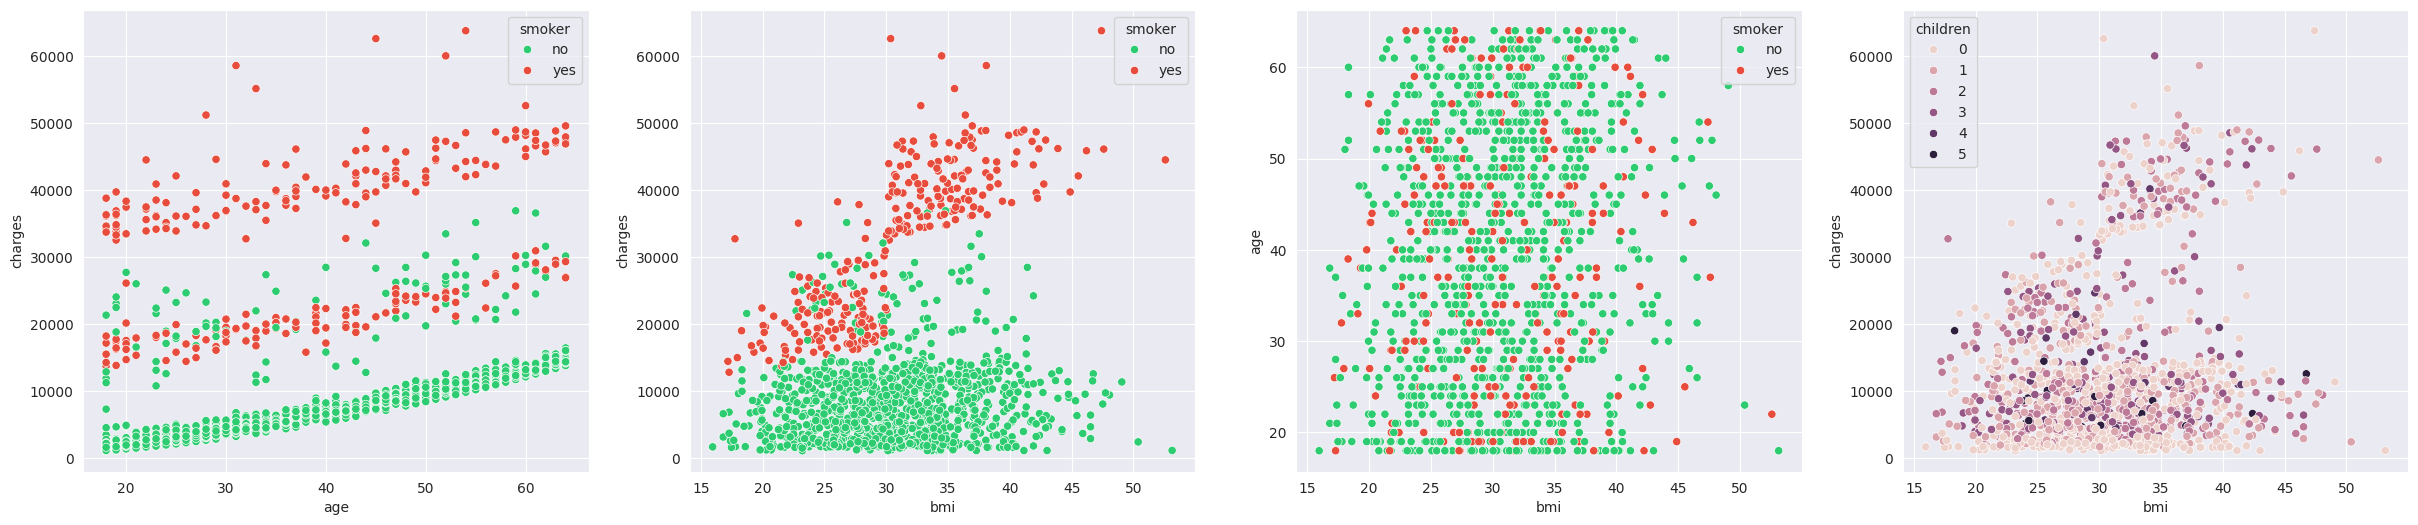

In [16]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(30, 6))

sns.scatterplot(
    data,
    y='charges',
    x='age',
    hue='smoker',
    palette=paleta['smoker'],
    hue_order=['no', 'yes'],
    ax=ax[0]
)

sns.scatterplot(
    data,
    y='charges',
    x='bmi',
    hue='smoker',
    palette=paleta['smoker'],
    hue_order=['no', 'yes'],
    ax=ax[1]
)

sns.scatterplot(
    data,
    y='age',
    x='bmi',
    hue='smoker',
    palette=paleta['smoker'],
    hue_order=['no', 'yes'],
    ax=ax[2]
)

sns.scatterplot(
    data,
    y='charges',
    x='bmi',
    hue='children',
    # palette=paleta['region'],
    #hue_order=['southwest', 'southeast', 'northwest', 'northeast'],
    ax=ax[3]
)

plt.show()

**charges vs age**

- A positive relationship is observed between age and medical charges. As age increases, medical costs tend to rise.
- Smokers consistently have much higher medical charges than non-smokers.
- This indicates that smoking acts as a multiplier of medical risk, resulting in significantly higher costs

**charges vs bmi**
- BMI alone does not fully explain medical costs but appears to have a strong effect in combination with smoking.
- Among non-smokers, medical charges remain relatively low even when BMI is high.
- In contrast, for smokers, medical costs increase substantially when BMI exceeds approximately 30, corresponding to obesity levels.
- This suggests an interaction between BMI and smoking, meaning the impact of BMI on medical costs is not the same for all individuals: it is much greater for smokers.

**age vs bmi**
- The third plot shows no strong relationship between age and BMI.
- BMI values are relatively evenly distributed across all ages, indicating that in this dataset:
- Young individuals can have both low and high BMI values.
- Older individuals also present a wide range of BMI values.

**charges vs bmi and children**

 - No clear clustering is observed that would suggest the number of children has a strong impact on medical charges.

**Hypothesis definition**
---

**Hypothesis 1**



**Research question**
- Do smokers have higher average medical expenses than non-smokers?

**Response variable**
- charges

**Explanatory variable**
- smoking status (smoker vs. non-smoker)

**Population parameter**
- Population mean medical expense

**Statistical hypothesis**

- H₀: μ_smoker <= μ_nonsmoker
- H₁: μ_smoker > μ_nonsmoker

**Statistical test**
- Independent two-sample t-test

**Hypothesis testing conclusion**


In [17]:
smokers = data[data['smoker'] == 'yes']['charges']
nonsmokers = data[data['smoker'] == 'no']['charges']

t_stat, p_value = ttest_ind(smokers, nonsmokers, equal_var=False, alternative='greater')
print(t_stat, p_value)

32.751887766341824 2.94473222335849e-103


In [18]:
if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to reject H0")

Reject H0


Using an independent two-sample t-test with a one-sided alternative hypothesis μ_smoker > μ_nonsmoker, the results show a statistically significant difference p-value < 0.05. Therefore, we reject the null hypothesis and conclude that smokers have higher average medical expenses than non-smokers.

**Hypothesis 2**

**Research question**

- Is the population mean BMI greater than 30?

**Response variable**
- bmi

**Explanatory variable**
- There is no group. It is compared against a reference value

**Population parameter**

- μ_bmi: Population mean BMI

**Statistical hypothesis**


- H₀: μ_bmi = 30

- H₁: μ_bmi > 30

**Statistical test**
- one-sample t-test


**Hypothesis testing conclusion**


In [19]:
t_stat, p_value = ttest_1samp(data["bmi"], 30)
print(t_stat, p_value)

3.9792455329981693 7.284478321088481e-05


In [20]:
if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to reject H0")

Reject H0



Mediante una prueba t de Student de una muestra con una hipótesis alternativa unilateral (μ > 30), los resultados muestran una diferencia estadísticamente significativa (valor p < 0,05). Por lo tanto, rechazamos la hipótesis nula y concluimos que el BMI promedio poblacional es mayor que 30.

**Hypothesis 3**

**Research question**

Is the average medical expenditure different across regions?

**Response variable**

charges

**Explanatory variable**

region

**Population parameter**

Population means by region

- μ_NE
- μ_NW
- μ_SE
- μ_SW

**Statistical hypothesis**

H₀: μ_NE = μ_NW = μ_SE = μ_SW

H₁: At least one mean is different



**Statistical test**

ANOVA

**Hypothesis testing conclusion**

In [21]:
groups = [d["charges"].values for _, d in data.groupby("region")]

f_stat, p_value = f_oneway(*groups)

print(f_stat, p_value)

2.9696266935891193 0.0308933560705201


Using a one-way ANOVA to compare average medical expenses across regions, the results show an F-statistic of 2.97 with a p-value of 0.031. Since the p-value is less than 0.05, we reject the null hypothesis and conclude that there is a statistically significant difference in average medical expenses between at least two regions